In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
archivo = "/content/drive/MyDrive/CIENCIA DE DATOS/Diabetes/diabetes (1).csv"
completo = pd.read_csv(archivo)

for df in (completo,):
  df.columns = [str(c).strip() for c in df.columns]

columnas_nulas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']    # Variables donde 0 representa un valor nulo

In [ ]:
# 2. Separación en Completo, Depurado y Excluidas
depurado = completo.copy()
filtro_ceros = (depurado[columnas_nulas] == 0).any(axis=1)

excluidas = depurado[filtro_ceros].copy()
depurado = depurado[~filtro_ceros].dropna().copy()
completo = completo.dropna().copy()

print(f"Registros totales: {len(completo):,}")
print(f"Registros depurados: {len(depurado):,}")
print(f"Registros excluidos: {len(excluidas):,}")

display(completo.head(10))

Registros totales: 768
Registros depurados: 768
Registros excluidos: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


**Medidas de tendencia central**

|Medida | Definicion | Utilidad |
|---|---|---|
|Media| Suma de frecuencias divida entre palabras unicas|Frecuencia promedio, sensible a plabras extremadamente repetidas|
|Mediana| Valor central de las frecuencias ordenadas | Describe mejor una dsitribucion no simetrica|
|Moda| Frecuencia que ocurre en mas palabras|Mostrar muchos palabras que aparecen una vez|
|Cuartiles|Dividen los datos ordenados en 4 partes|Localizar el 25%, 50% y 75% de las frecuencias|
|Varianza| Promedio de desviaciones cuadraticas con respecto a la media| Cualifica la dispercion|
|Desviacion Estandar| raiz de la varianza | Dispersion en las mismas unidades de frecuencia|
|IQR - Rango Intercuartilico| Q3 - Q1 | Mide una dispersion mas robusta del 50% central|
|Asimetria| Mide la falta de simetria| Un valor alto revela una cola de palabras muy frecuentes|
|Gini| Sirve para medir la desigualdad economica o la concentracion de ingresos de una poblacion|Medir que tan aprecida o diferente es la distribucion de los recursos de un grupo de personas|
|Entropia|Medir el grado de desorden, caos o incertidumbre dentro de un sistema|Medir la incertidumbre, el desorden o la perdida de control en cualquier sistema|

In [ ]:
# Funciones de gini y entropia
def gini(valores):
    x = np.sort(np.asarray(valores, dtype=float))
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

def entropia_normalizada(valores):
    p = np.asarray(valores, dtype=float)
    p = p[p > 0]
    if len(p) <= 1 or p.sum() == 0:
        return 0.0
    p = p / p.sum()
    h = -(p * np.log(p)).sum()
    return h / np.log2(len(p))

In [ ]:
def resumen_estadistico(df,nombre):
  if df.empty:
        return pd.Series({"Corpus": nombre})

  # Extraemos todos los valores de las columnas biométricas
  f = pd.Series(df[columnas_nulas].values.flatten()).dropna()
  modos = f.mode().tolist()
  return pd.Series({
        "Corpus": nombre,
        "Suma total valores": int(f.sum()),
        "Total datos": int(f.size),
        "Media": f.mean(),
        "Mediana": f.median(),
        "Moda": ", ".join(map(str, modos[:3])),
        "Q1(25%)": f.quantile(.25),
        "Q2(50%)": f.quantile(.50),
        "Q3(75%)": f.quantile(.75),
        "Q90": f.quantile(.90),
        "Q95": f.quantile(.95),
        "Máximo": f.max(),
        "Rango": f.max() - f.min(),
        "Varianza muestral": f.var(ddof=1),
        "Desviación estándar muestral": f.std(ddof=1),
        "Asimetria": f.skew(),
        "Curtosis exceso": f.kurt(),
        "Diversidad de datos": f.nunique() / f.sum() if f.sum() != 0 else 0,
        "Entropía normalizada": entropia_normalizada(f),
        "Gini": gini(f),
    })

In [ ]:
# Tabla final
resumen = pd.DataFrame([
    resumen_estadistico(completo, "Completo"),
    resumen_estadistico(depurado, "Depurado"),
    resumen_estadistico(excluidas, "Excluidas")
]).set_index("Corpus").T


display(resumen)

Corpus,Completo,Depurado,Excluidas
Suma total valores,305160.0,305160.0,NaN
Total datos,3840.0,3840.0,NaN
Media,79.468958,79.468958,NaN
Mediana,70.0,70.0,NaN
Moda,102.5,102.5,NaN
Q1(25%),32.0,32.0,NaN
Q2(50%),70.0,70.0,NaN
Q3(75%),102.5,102.5,NaN
Q90,158.1,158.1,NaN
Q95,171.0,171.0,NaN


In [ ]:
# ¿Qué causa la diabetes por el momento?
"Con el análisis realizado hasta ahora, incluyendo la organización de los datos, su limpieza y las estadísticas descriptivas, todavía no es posible determinar con certeza cuáles son las causas de la diabetes. Para obtener una conclusión más clara, sería necesario realizar un análisis exploratorio más detallado y utilizar modelos estadísticos que permitan identificar posibles relaciones entre las diferentes características y la variable Outcome."

'Con el análisis realizado hasta ahora, incluyendo la organización de los datos, su limpieza y las estadísticas descriptivas, todavía no es posible determinar con certeza cuáles son las causas de la diabetes. Para obtener una conclusión más clara, sería necesario realizar un análisis exploratorio más detallado y utilizar modelos estadísticos que permitan identificar posibles relaciones entre las diferentes características y la variable Outcome.'

In [ ]:
!pip install statsmodels

In [ ]:
!pip install wquantiles

In [ ]:
from scipy.stats import trim_mean #Media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
completo.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
486,1,139,62.0,41,480.0,40.7,0.536,21,0
401,6,137,61.0,27,102.5,24.2,0.151,55,0
536,0,105,90.0,27,102.5,29.6,0.197,46,0
613,6,105,80.0,28,102.5,32.5,0.878,26,0
253,0,86,68.0,32,102.5,35.8,0.238,25,0
87,2,100,68.0,25,71.0,38.5,0.324,26,0
319,6,194,78.0,32,169.5,23.5,0.129,59,1
457,5,86,68.0,28,71.0,30.2,0.364,24,0
142,2,108,52.0,26,63.0,32.5,0.318,22,0
255,1,113,64.0,35,169.5,33.6,0.543,21,1


In [ ]:
completo.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
completo.DiabetesPedigreeFunction.mean()

np.float64(0.47187630208333325)

In [ ]:
trim_mean(completo.DiabetesPedigreeFunction, 0.1)

np.float64(0.42155357142857147)

In [ ]:
completo.DiabetesPedigreeFunction.median()

0.3725

In [ ]:
# Media ponderada de Pedigree Function
np.average(completo.DiabetesPedigreeFunction, weights=completo.Pregnancies)

np.float64(0.4621554351506942)

In [ ]:
wquantiles.median(completo.DiabetesPedigreeFunction, weights=completo.Pregnancies)

np.float64(0.3663333333333333)

<Axes: >

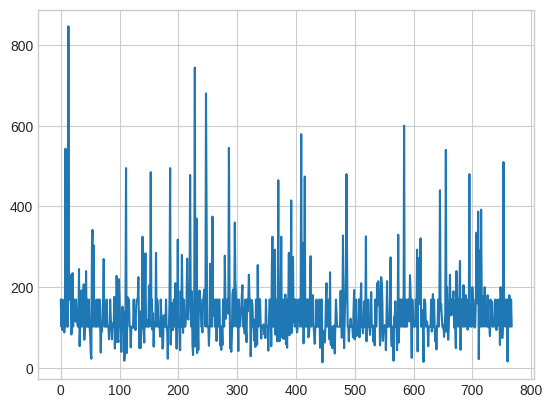

In [ ]:
completo.Insulin.plot.line()

<Axes: >

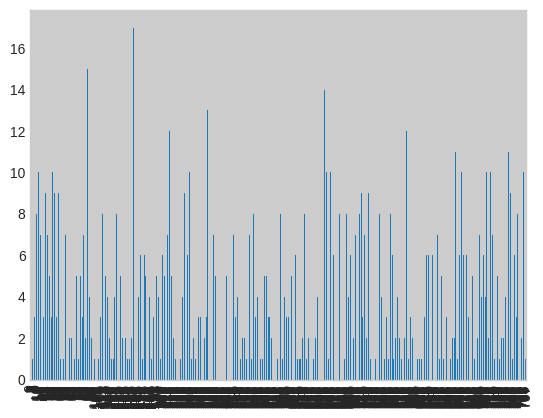

In [ ]:
completo.Pregnancies.plot.bar()

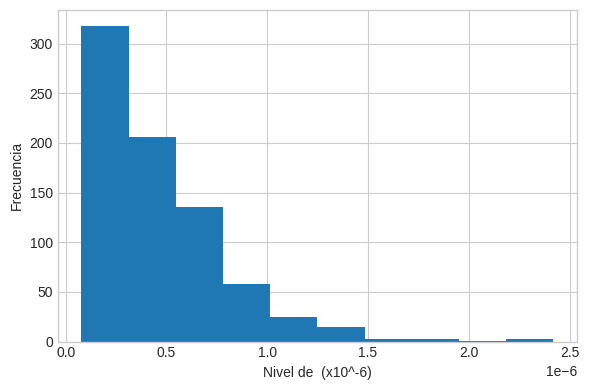

In [ ]:
ax = (completo.DiabetesPedigreeFunction/1_000_000).plot.hist(figsize=(6,4))
ax.set_xlabel("Nivel de  (x10^-6)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()

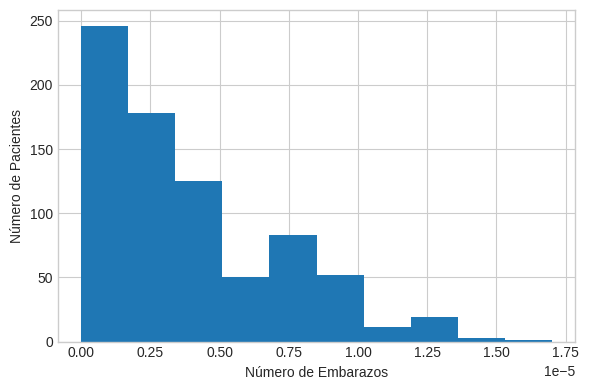

In [ ]:
ax = (completo.Pregnancies/1_000_000).plot.hist(figsize=(6,4))
ax.set_xlabel("Número de Embarazos")
ax.set_ylabel("Número de Pacientes")
plt.tight_layout()

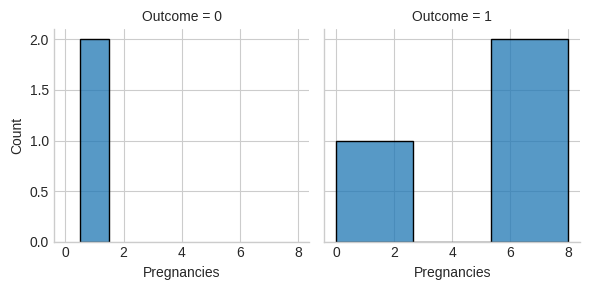

In [ ]:
analisis = completo.head()
g = sns.FacetGrid(analisis,col="Outcome")
g.map(sns.histplot,"Pregnancies")

Estimación de la variabilidad

In [ ]:
# Desviación estandar
completo.Insulin.std()

89.10084663622659

In [ ]:
completo.Pregnancies.std()

3.3695780626988623

In [ ]:
# Calculo del IQR
completo.Insulin.quantile(0.75) - completo.Insulin.quantile(0.25)

np.float64(67.0)

In [ ]:
completo.Pregnancies.quantile(0.75) - completo.Pregnancies.quantile(0.25)

np.float64(5.0)

Exploración de distribucion de datos con graficos

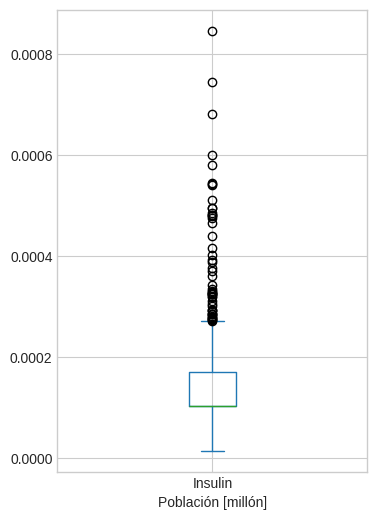

In [ ]:
ax=(completo.Insulin/1_000_000).plot.box(figsize=(4,6))
ax.set_xlabel("Población [millón]")

plt.show()

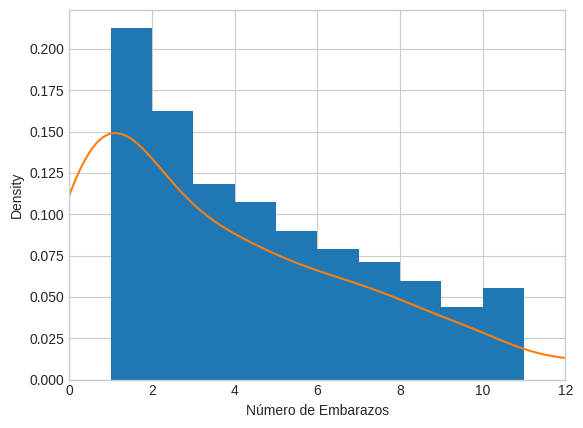

In [ ]:
ax=(completo["Pregnancies"]).plot.hist(density=True, xlim=[0,12],bins=range(1,12))
completo["Pregnancies"].plot.density(ax=ax)
ax.set_xlabel("Número de Embarazos")

plt.show()

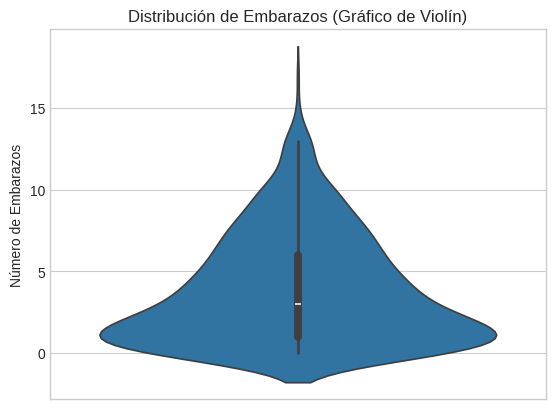

In [ ]:
ax = sns.violinplot(y=completo["Pregnancies"])
ax.set_title("Distribución de Embarazos (Gráfico de Violín)")
ax.set_ylabel("Número de Embarazos")
plt.show()

In [ ]:
mad_DiabetesPedigreeFunction = robust.mad(completo.Insulin)
mad_pregnancies = robust.mad(completo.Pregnancies)

print(f"Desviación Absoluta de la Mediana (MAD) - Insulina: {mad_DiabetesPedigreeFunction:.2f} mg/dL")
print(f"Desviación Absoluta de la Mediana (MAD) - Embarazos: {mad_pregnancies:.2f}")

# Comparación con la Desviación Estándar para ver el efecto de los outliers
print(f"\nDesviación Estándar para comparar: {completo.DiabetesPedigreeFunction.std():.2f} mg/dL")

Desviación Absoluta de la Mediana (MAD) - Insulina: 54.11 mg/dL
Desviación Absoluta de la Mediana (MAD) - Embarazos: 2.97

Desviación Estándar para comparar: 0.33 mg/dL


In [ ]:
### ¿Se puede responder qué causa la diabetes con el análisis actual?

"""No, el análisis realizado hasta ahora es puramente descriptivo y exploratorio. Hemos examinado las distribuciones de variables individuales y algunas estadísticas básicas, lo cual nos ayuda a entender los datos, pero no es suficiente para establecer relaciones de causa y efecto. Para determinar qué causa la diabetes, necesitaríamos realizar análisis de correlación más profundos y aplicar modelos estadísticos o predictivos que cuantifiquen la influencia de cada característica en el Outcome (presencia de diabetes)."""

'No, el análisis realizado hasta ahora es puramente descriptivo y exploratorio. Hemos examinado las distribuciones de variables individuales y algunas estadísticas básicas, lo cual nos ayuda a entender los datos, pero no es suficiente para establecer relaciones de causa y efecto. Para determinar qué causa la diabetes, necesitaríamos realizar análisis de correlación más profundos y aplicar modelos estadísticos o predictivos que cuantifiquen la influencia de cada característica en el Outcome (presencia de diabetes).'